# Exploratory Data Analysis

## MRNet

### Before `torchio.transforms`

In [1]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import math
import torchio as tio

/home/qj474765/master_thesis/MedSliM/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load an image
nifti_file_path = '/hpcwork/rwth1833/datasets/preprocessed/MRNet/train/sagittal/1129.nii.gz'
image = nib.load(nifti_file_path).get_fdata()
image.shape

(256, 256, 34)

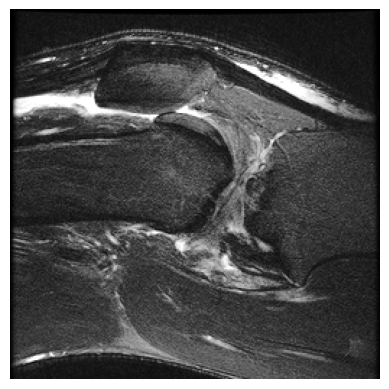

In [3]:
slice_idx = image.shape[-1] // 2
plt.imshow(image[:, :, slice_idx], cmap='gray')
plt.axis('off')
plt.show()

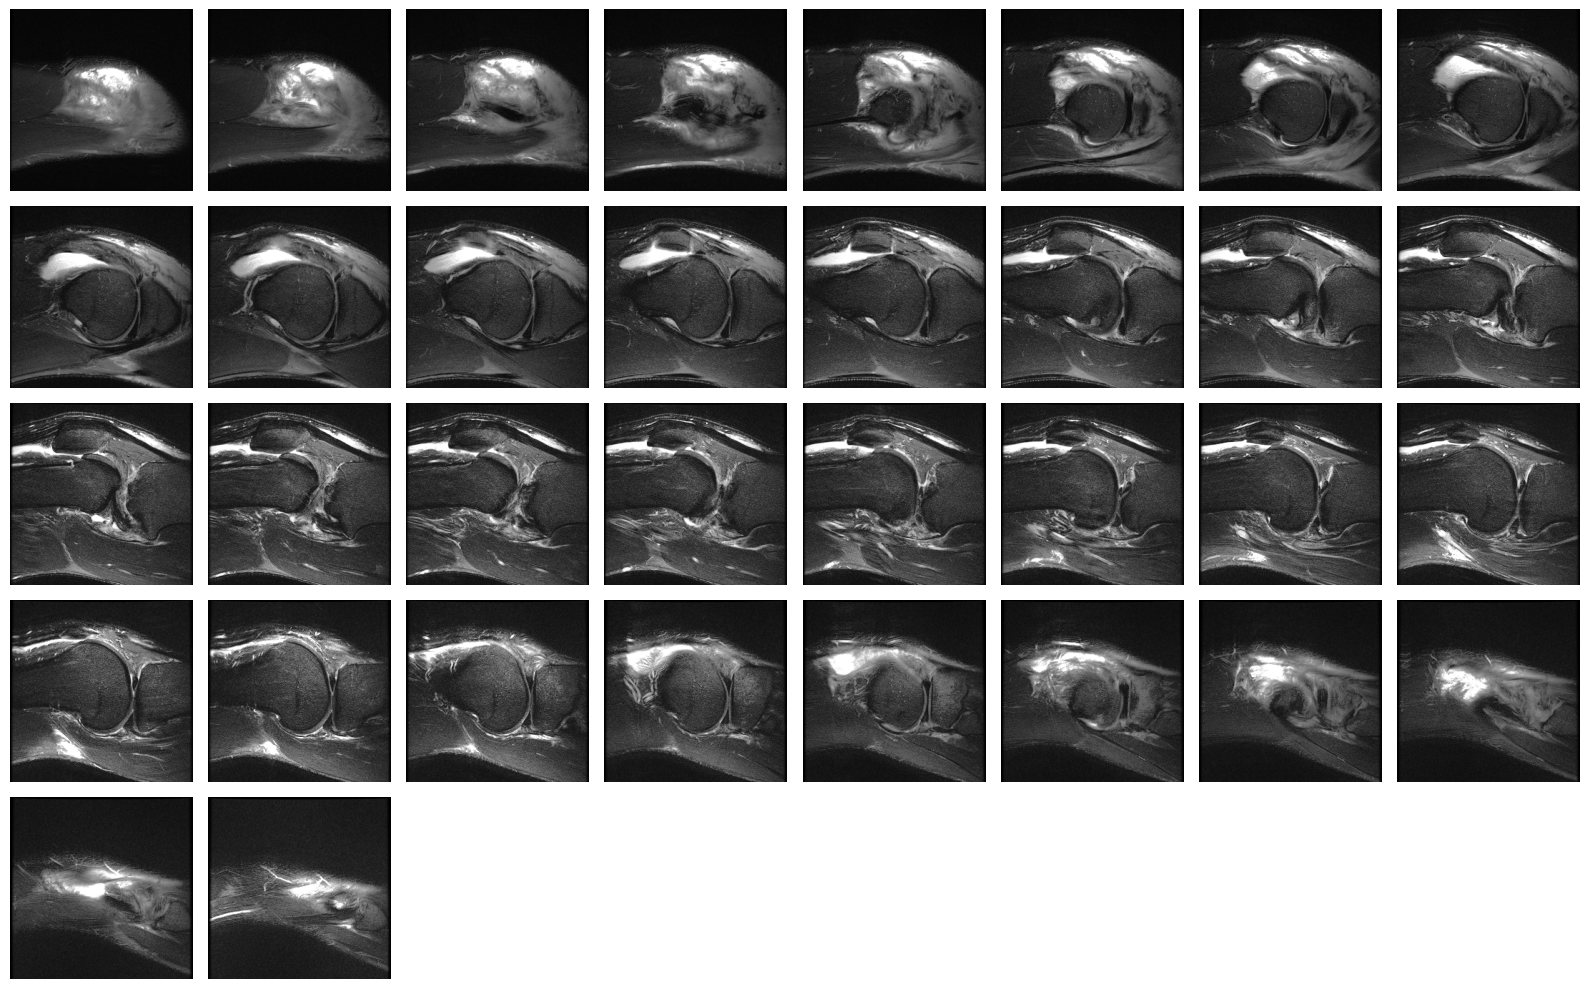

In [4]:
num_slices = image.shape[-1]
n_cols = 8
n_rows = math.ceil(num_slices / n_cols)

plt.figure(figsize=(n_cols * 2, n_rows * 2))
for i in range(num_slices):
    plt.subplot(n_rows, n_cols, i + 1)
    plt.imshow(image[:, :,i], cmap='gray')
    plt.axis('off')
plt.tight_layout()
plt.show()

### After `torchio.transforms`

In [10]:
from med_slim.utils.preprocessing.transforms import get_transforms
_, val_tf = get_transforms(model_name="dinov2", num_slices=32, to_tensor=True)

In [11]:
original_image = tio.ScalarImage(nifti_file_path)
print(f"Original image shape: {original_image.shape}")
print(f"Original image spacing: {original_image.spacing}")

Original image shape: (1, 256, 256, 34)
Original image spacing: (1.0, 1.0, 1.0)


In [12]:
transformed_image = val_tf(original_image)
print(f"Transformed image shape: {transformed_image.shape}")

Transformed image shape: torch.Size([1, 32, 224, 224])


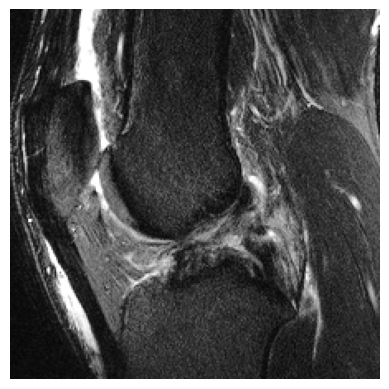

In [13]:
transformed_image = transformed_image.numpy().squeeze(axis=0) # Remove channel dimension for visualization 
plt.imshow(transformed_image[slice_idx], cmap='gray')
plt.axis('off')
plt.show()

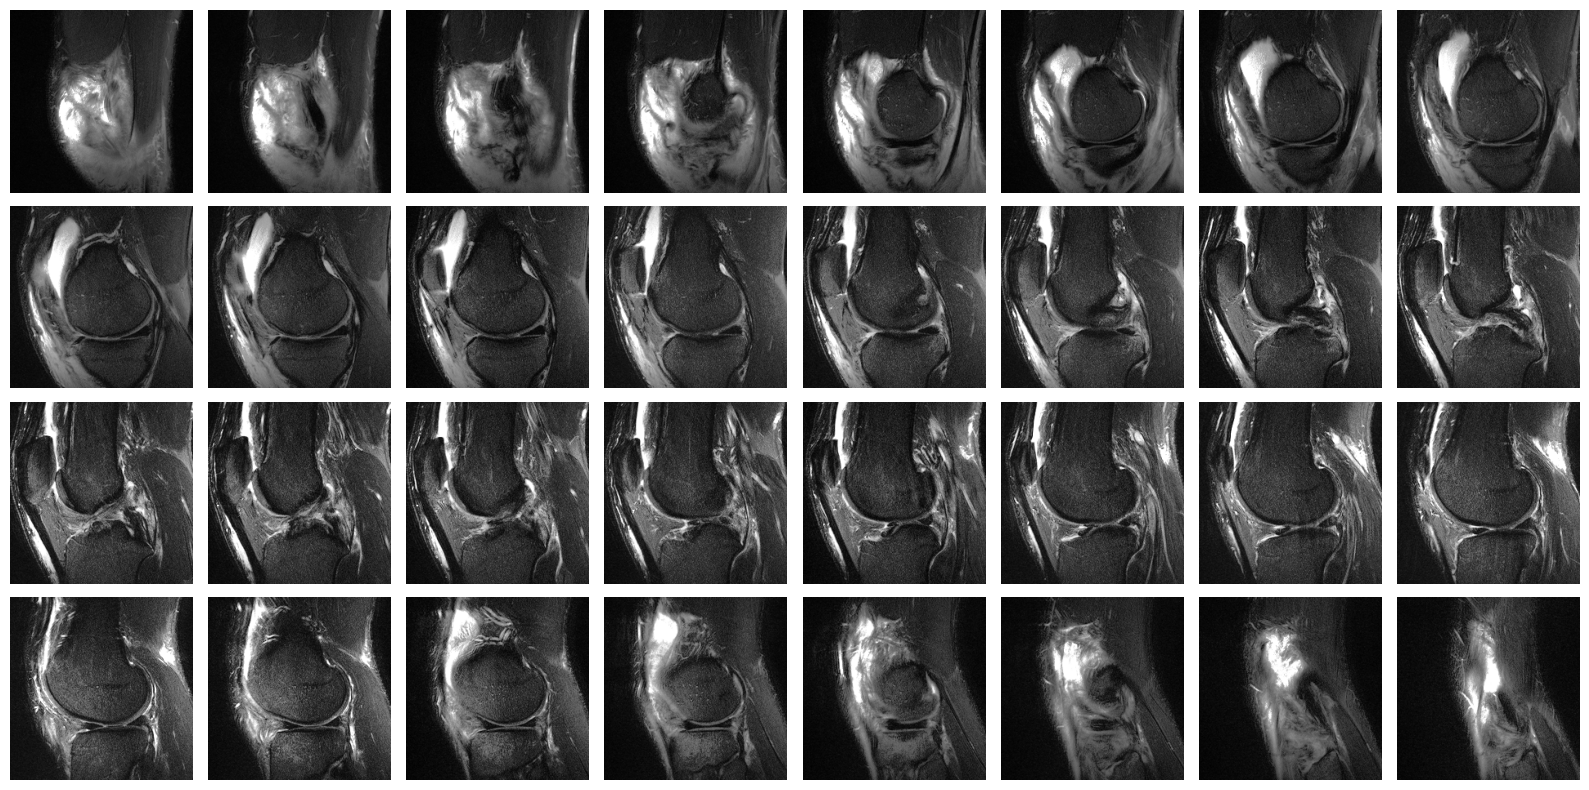

In [14]:
num_slices = transformed_image.shape[0]
n_cols = 8
n_rows = math.ceil(num_slices / n_cols)

plt.figure(figsize=(n_cols * 2, n_rows * 2))
for i in range(num_slices):
    plt.subplot(n_rows, n_cols, i + 1)
    plt.imshow(transformed_image[i], cmap='gray')
    plt.axis('off')
plt.tight_layout()
plt.show()